**Configuration**

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
IMAGE_SIZE = 64
BATCH_SIZE = 32
LATENT_DIM = 100
EPOCHS = 10

**Dataset**

In [ ]:
import zipfile
import os

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("/content/archive")

# Based on your clarification and previous output, the images are likely in /content/archive/data
image_dir = "/content/archive/data"

if os.path.exists(image_dir):
    all_image_paths = [os.path.join(image_dir, fname) for fname in os.listdir(image_dir) if fname.endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Found {len(all_image_paths)} image files in {image_dir}")
    # Display a few image paths as an example
    for i, path in enumerate(all_image_paths[:5]):
        print(f"  {path}")
else:
    print(f"Error: Directory {image_dir} not found. Please check the extracted path or file locations.")





Found 21551 image files in /content/archive/data
  /content/archive/data/6058.png
  /content/archive/data/2641.png
  /content/archive/data/21427.png
  /content/archive/data/2052.png
  /content/archive/data/5706.png


In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    image_dir,
    image_size=(64,64),
    batch_size=BATCH_SIZE,
    label_mode=None
)

for batch in train_dataset.take(1):
    print(batch.shape)

Found 43102 files.
(32, 64, 64, 3)


In [ ]:
def preprocess(image):
    image = (image / 127.5) - 1
    return image
train_dataset = train_dataset.map(preprocess)


**Generator**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Reshape, BatchNormalization, Conv2DTranspose, ReLU, Activation

def generator():
  model = Sequential()
  model.add(Input(shape=(100,))) # Changed 100, to (100,)
  model.add(Dense(8192))
  model.add(Reshape((4, 4, 512)))
  model.add(Conv2DTranspose(256,(4,4),strides=(2,2), padding="same"))
  model.add(BatchNormalization())
  model.add(ReLU())
  model.add(Conv2DTranspose(128,(4,4),strides=(2,2), padding="same"))
  model.add(BatchNormalization())
  model.add(ReLU())
  model.add(Conv2DTranspose(64,(4,4),strides=(2,2), padding="same"))
  model.add(BatchNormalization())
  model.add(ReLU())
  model.add(Conv2DTranspose(3,(4,4),strides=(2,2), padding="same"))
  model.add(Activation("tanh"))
  return model # Added this line to return the model


generator_model = generator()
generator_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8192)           │       827,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_12             │ (None, 8, 8, 256)      │     2,097,408 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_13             │ (None, 16, 16, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_14             │ (None, 32, 32, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_15             │ (None, 64, 64, 3)      │         3,075 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585,219 (13.68 MB)

 Trainable params: 3,584,323 (13.67 MB)

 Non-trainable params: 896 (3.50 KB)

**Discriminator**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Conv2D, LeakyReLU, Flatten


def discriminator():
  model = Sequential()
  model.add(Input(shape=(64,64,3)))
  model.add(Conv2D(64, (4,4), strides=(2,2), padding="same"))
  model.add(LeakyReLU())
  model.add(Conv2D(128, (4,4), strides=(2,2), padding="same"))
  model.add(BatchNormalization())
  model.add(LeakyReLU())
  model.add(Conv2D(256, (4,4), strides=(2,2), padding="same"))
  model.add(BatchNormalization())
  model.add(LeakyReLU())
  model.add(Conv2D(512, (4,4), strides=(2,2), padding="same"))
  model.add(BatchNormalization())
  model.add(LeakyReLU())
  model.add(Flatten())
  model.add(Dense(1, activation='sigmoid')) # Changed Sigmoid() to activation='sigmoid'
  return model

discriminator_model = discriminator()
discriminator_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 512)      │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,768,321 (10.56 MB)

 Trainable params: 2,766,529 (10.55 MB)

 Non-trainable params: 1,792 (7.00 KB)

**Training**

In [ ]:
from tensorflow.keras.models import Model # Added Model import

discriminator_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

discriminator_model.trainable = False

noise_input = Input(shape=(100,))
generated_image = generator_model(noise_input)
gan_output = discriminator_model(generated_image)
gan_model = Model(noise_input, gan_output)


gan_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
)
gan_model.summary()

Model: "functional_117"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_8 (Sequential)       │ (None, 64, 64, 3)      │     3,585,219 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_9 (Sequential)       │ (None, 1)              │     2,768,321 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,353,540 (24.24 MB)

 Trainable params: 3,584,323 (13.67 MB)

 Non-trainable params: 2,769,217 (10.56 MB)

In [ ]:
noise_dim = 100
noise = tf.random.normal([1,noise_dim])

fake_image = generator_model(noise)
print(f'Generated image shape: {fake_image.shape}')

prediction = discriminator_model(fake_image)
print(f'Discriminator output: {prediction}')

**Results**

In [ ]:
def train_step(real_images):

    batch_size = real_images.shape[0]

    # -----------------------
    # Train discriminator
    # -----------------------

    noise = tf.random.normal([batch_size, LATENT_DIM])

    fake_images = generator_model(noise)

    real_labels = tf.ones((batch_size, 1))
    fake_labels = tf.zeros((batch_size, 1))

    d_loss_real = discriminator_model.train_on_batch(
        real_images,
        real_labels
    )

    d_loss_fake = discriminator_model.train_on_batch(
        fake_images,
        fake_labels
    )


    # -----------------------
    # Train generator
    # -----------------------

    noise = tf.random.normal([batch_size, LATENT_DIM])

    misleading_labels = tf.ones((batch_size,1))

    g_loss = gan_model.train_on_batch(
        noise,
        misleading_labels
    )

    return d_loss_real, d_loss_fake, g_loss

In [ ]:
for batch in train_dataset.take(1):
    d_real, d_fake, g_loss = train_step(batch)

    print("Discriminator real:", d_real)
    print("Discriminator fake:", d_fake)
    print("Generator:", g_loss)

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Discriminator real: [array(0.69711363, dtype=float32), array(0.375, dtype=float32)]
Discriminator fake: [array(0.6950852, dtype=float32), array(0.609375, dtype=float32)]
Generator: 0.69818306


In [ ]:
for epoch in range(EPOCHS):

    print(f"Epoch {epoch+1}/{EPOCHS}")

    for batch in train_dataset:
        d_real, d_fake, g_loss = train_step(batch)

    print(
        "D real:",
        d_real[0],
        "D fake:",
        d_fake[0],
        "G:",
        g_loss
    )

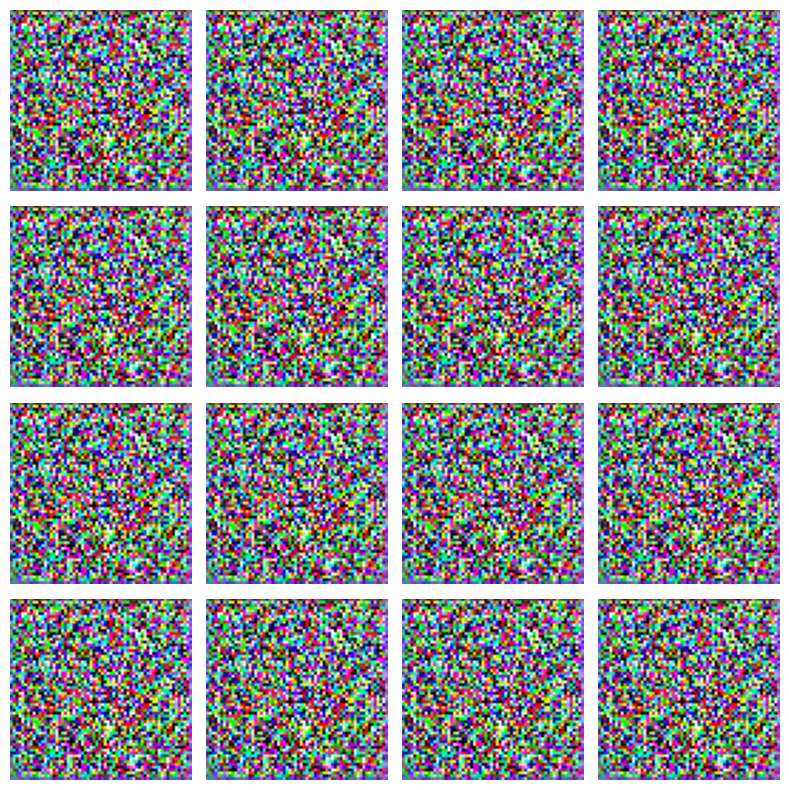

In [ ]:
# =========================
# Generate Anime Faces
# =========================

# Create fixed noise so we can reproduce the same generated images
seed = tf.random.normal([16, LATENT_DIM])


def generate_images(model, noise):
    images = model(noise)

    # Convert from [-1,1] back to [0,1]
    images = (images + 1) / 2

    # Clip values just in case
    images = tf.clip_by_value(images, 0, 1)

    return images


def show_images(images):
    plt.figure(figsize=(8, 8))

    for i in range(len(images)):
        plt.subplot(4, 4, i + 1)

        plt.imshow(images[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Generate images
generated_images = generate_images(generator_model, seed)

# Display images
show_images(generated_images)